# Seminar 2

In this seminar we train different VAD models.

Dataset: https://disk.yandex.ru/d/LJlkc_WMo-libA

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import requests
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import urllib

import IPython

### Download data

In [2]:
import requests
from urllib.parse import urlencode
from io import BytesIO
from tarfile import TarFile
import tarfile

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/LJlkc_WMo-libA'
dst_path = '/home/jupyter/mnt/datasets/voice_activity_detection/' # if we make the Datasphere datasets work
dst_path = './dataset_seminar/'

final_url = base_url + urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']

# if you aren't in the Datasphere
# !wget -O data_sem.tar.gz "{download_url}"
# !tar -xf data_sem.tar.gz

# otherwise
# response = requests.get(download_url)
# io_bytes = BytesIO(response.content)
# tar = tarfile.open(fileobj=io_bytes, mode='r:gz')
# tar.extractall(path=dst_path)


In [ ]:
DATADIR = dst_path + '/data'
WAVDIR = os.path.join(DATADIR, 'wav')
ALIGNDIR = os.path.join(DATADIR, 'align')
FS = 16000
# NOTE: frames are not overlapping!
FRAME = 30 * FS // 1000
TRAIN = 350
DEVICE = 'mps' # 'cpu'

In [6]:
class Dataset:
    def __init__(self):
        uttids = [uttid.split('.')[0] for uttid in os.listdir(WAVDIR)]
        self._data = []
        for uttid in uttids:
            wav_path = os.path.join(WAVDIR, f'{uttid}.wav')
            wav, fs = torchaudio.load(wav_path)
            assert fs == FS
            align = np.load(os.path.join(ALIGNDIR, f'{uttid}.npy'))
            while align.shape[0] * FRAME > wav.shape[1]:
                align = align[:-1]
            self._data.append((wav[:, :align.shape[0] * FRAME], align, wav_path))

    def __getitem__(self, idx: int):
        return self._data[idx]

    def __len__(self):
        return len(self._data)

dataset = Dataset()

### Sample

Let's take a look at audiofile, its waveform and its align targets: 

In [7]:
dataset[0][0], dataset[0][1]

(tensor([[ 6.1035e-05, -3.0518e-05, -1.2207e-04,  ..., -1.2512e-03,
          -1.0986e-03, -9.1553e-04]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32))

In [8]:
dataset[0][0].shape, dataset[0][1].shape

(torch.Size([1, 37440]), (78,))

In [ ]:
IPython.display.Audio(dataset[0][2])

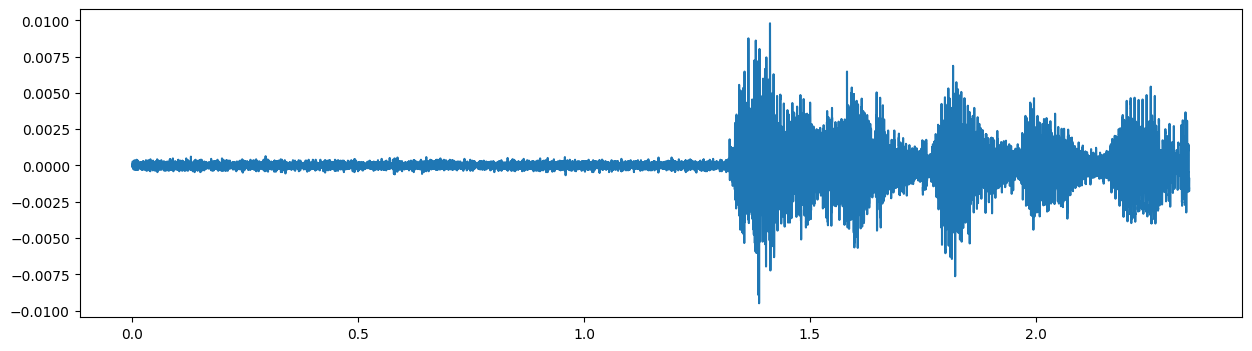

In [10]:
plt.figure(figsize=(15, 4))
plt.plot(np.arange(0, dataset[0][0].shape[1] / FS, 1 / FS), dataset[0][0][0])
plt.show()

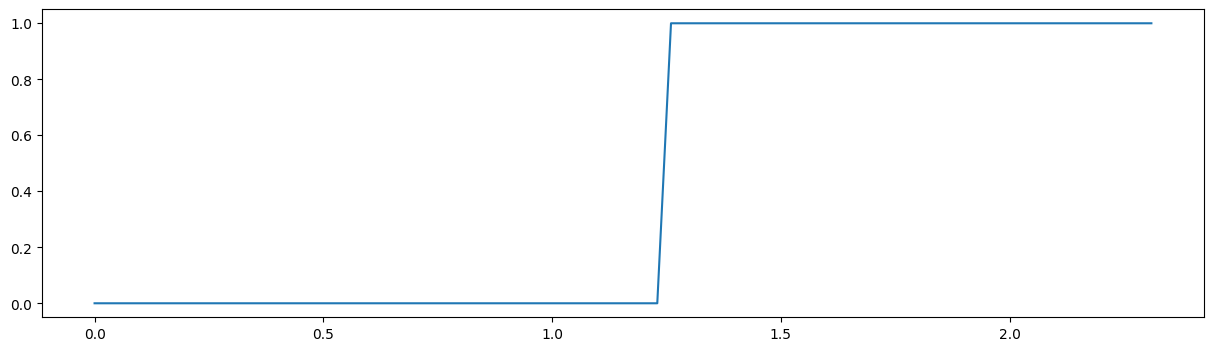

In [11]:
plt.figure(figsize=(15, 4))
plt.plot(np.arange(0, dataset[0][1].shape[0] * 0.03 - 1e-6, 0.03), dataset[0][1])
plt.show()

### Score and Tuning

A large number of metrics can be used for the vad task. Let's try to implement the following:
- Per-frame Accuracy $\frac{\sum_i^N \sum_j^{A_i} I(A_{ij} = P_{ij})}{\sum_i^N \sum_j^{A_i} 1}$
- Per-frame Accuracy with utterance normalization $\frac{1}{N} \sum_i^N \frac{\sum_j^{A_i} I(A_{ij} = P_{ij})}{\sum_j^{A_i} 1}$
- Intersection-over-Union $\frac{1}{N} \sum_i^N \frac{\sum_j^{A_i} I(A_{ij} = P_{ij} = 1)}{\sum_j^{A_i} I(A_{ij} = 1 || P_{ij} = 1)}$

where:
- $N$ -- number of utterances
- $A_{ij}$ -- target for $j$-th frame of $i$-th utterance
- $P_{ij}$ -- predict for $j$-th frame of $i$-th utterance

In [57]:
def score(probs: list[np.ndarray], aligns: list[np.ndarray], thr: float = 0.5):
    preds = [prob > thr for prob in probs]
    # flat_preds = np.concat(preds)
    # flat_targets = np.concat(aligns)
    # frame_acc = (flat_preds == flat_targets).sum() / flat_targets.shape[0]
    frame_acc = sum((p == a).sum() for p, a in zip(preds, aligns)) / sum(a.shape[0] for a in aligns)
    avg_acc = np.mean([np.mean(p == a) for p, a in zip(preds, aligns)])
    iou = np.mean([(p & a).sum() / (p | a).sum() for p, a in zip(preds, aligns)])
    return float(frame_acc), float(avg_acc), float(iou)

In [58]:
score([np.array([0.1, 0.2])], [np.array([0, 1])], thr=0.5)

(0.5, 0.5, 0.0)

Let's write function to find optimal thresholds for per-frame Accuracy metric:

In [83]:
np.arange(10).clip(0, 1)

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [90]:
def optimal_thresold(preds: list[np.ndarray], align: list[np.ndarray]):
    best_thr = 0
    best_acc = 0

    thresholds = sorted(np.unique(np.concat(preds)).clip(0, 1))
    for thr in thresholds:
        cur_frame_acc, _, _ = score(preds, align, thr)
        if cur_frame_acc > best_acc:
            best_thr = thr
            best_acc = cur_frame_acc
        
    return best_thr, best_acc

### Energy VAD

Energy for one frame can be calculated as follows:
$$\frac{1}{N} \sum_i^N x_i^2$$
Where $N$ -- number of amplitudes in frame, $x_i$ -- $i$-th amplitude value.

We can get rid of $\frac{1}{N}$ in this formula, if all frames has the same size.

In [109]:
Y = np.concatenate([item[1] for item in dataset[:TRAIN]]) # [sum(n_frames for example in dataset)]
X = np.array(np.split(np.concatenate([item[0][0] for item in dataset[:TRAIN]]), Y.shape[0])) # [sum(n_frames for example in dataset), frame_size=FRAME]
Y_test = np.concatenate([item[1] for item in dataset[TRAIN:]])
X_test = np.array(np.split(np.concatenate([item[0][0] for item in dataset[TRAIN:]]), Y_test.shape[0]))
parts = np.cumsum([item[1].shape[0] for item in dataset[TRAIN:]])[:-1]
train_preds = np.mean(X ** 2, axis=1)
thr, train_acc = optimal_thresold([train_preds], [Y])
test_preds = np.mean(X_test ** 2, axis=1) > thr
test_score = score(np.split(test_preds, parts), np.split(Y_test, parts), thr)
print(train_acc, test_score)

0.9011240795864014 (0.9042538702501476, 0.8935556547197742, 0.6726715866328522)


In [110]:
X.shape, Y.shape

((51064, 480), (51064,))

In [ ]:
# reference
# 0.9011240795864014 (0.9042538702501476, 0.8935556547197742, 0.6726715866328522)

### Linear VAD

Let's try to use simple binary classification model for each frame.

In [132]:
def frame_classification(transform: nn.Module):
    X = np.concatenate([transform(item[0])[0].T.data.numpy()[:-1, :] for item in dataset[:TRAIN]])
    Y = np.concatenate([item[1] for item in dataset[:TRAIN]])
    print(X.shape, Y.shape)
    X_test = np.concatenate([transform(item[0])[0].T.data.numpy()[:-1, :] for item in dataset[TRAIN:]])
    Y_test = np.concatenate([item[1] for item in dataset[TRAIN:]])
    parts = np.cumsum([item[1].shape[0] for item in dataset[TRAIN:]])[:-1]
    model = LogisticRegression(random_state=123, max_iter=1000)
    model.fit(X, Y)
    train_preds = model.predict_proba(X)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]
    thr, train_acc = optimal_thresold([train_preds], [Y])
    test_score = score(np.split(test_preds, parts), np.split(Y_test, parts), thr)
    print(train_acc, test_score)

In [ ]:
# n_fft == hop_length --> windows in STFT do not overlap
frame_classification(torchaudio.transforms.MelSpectrogram(n_fft=FRAME, hop_length=FRAME, n_mels=23))

(51064, 23) (51064,)
0.9029257402475325 (0.9037544831343352, 0.8928250512833915, 0.6605857590582279)


In [134]:
# reference
# 0.9030628231239229 (0.9037544831343352, 0.893203583100323, 0.6654427992941193)

In [135]:
frame_classification(
    torchaudio.transforms.MFCC(n_mfcc=13, melkwargs={'n_mels': 23, 'n_fft': FRAME, 'hop_length': FRAME})
)

(51064, 13) (51064,)
0.9148715337615542 (0.90684160348663, 0.8965163243440217, 0.6874882405786664)


In [ ]:
# reference
# 0.9148519504934983 (0.9069324011440505, 0.8966098346910761, 0.6876653934667514)

### NN VAD

This is an unscored exercise, we are going to look at the homework instead

Let's try to aggregate adjacent frames:

In [171]:
from tqdm.auto import tqdm, trange

def multiframe_classification(transform: nn.Module, model: nn.Module):
    X = torch.cat([transform(item[0])[0].T.data[:-1, :] for item in dataset[:TRAIN]])
    Y = torch.cat([torch.from_numpy(item[1]) for item in dataset[:TRAIN]])
    print(X.shape, Y.shape)
    X_test = torch.cat([transform(item[0])[0].T.data[:-1, :] for item in dataset[TRAIN:]])
    Y_test = torch.cat([torch.from_numpy(item[1]) for item in dataset[TRAIN:]])
    parts = torch.cumsum(torch.tensor([item[1].shape[0] for item in dataset[TRAIN:]]), dim=0)[:-1]
    
    model.train()
    optimizer = torch.optim.SGD(model.parameters())
    loss_fn = torch.nn.BCELoss()
    for _ in trange(1000):
        optimizer.zero_grad()
        out = model(X.T)
        loss = loss_fn(out[0], Y.float())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.inference_mode():
        train_preds = model(X.T)[0].numpy()
        test_preds = model(X_test.T)[0].numpy()

    thr, train_acc = optimal_thresold([train_preds], [Y.numpy()])
    test_score = score(np.split(test_preds, parts), np.split(Y_test.numpy(), parts.numpy()), thr)
    print(train_acc, test_score)

In [172]:
multiframe_classification(
    torchaudio.transforms.MelSpectrogram(n_fft=FRAME, hop_length=FRAME, n_mels=23),
    nn.Sequential(nn.Conv1d(23, 23, 5, padding=2), nn.ReLU(), nn.Conv1d(23, 1, 1), nn.Sigmoid())
)

torch.Size([51064, 23]) torch.Size([51064])


100%|██████████| 1000/1000 [00:03<00:00, 257.42it/s]


0.9029453235155883 (0.9036636854769147, 0.8926058918434469, 0.6753448182134351)


In [ ]:
# reference
# 0.9011240795864014 (0.9042538702501476, 0.8935556547197742, 0.6726715866328522)

In [173]:
multiframe_classification(
    torchaudio.transforms.MFCC(n_mfcc=13, melkwargs={'n_mels': 23, 'n_fft': FRAME, 'hop_length': FRAME}),
    nn.Sequential(nn.Conv1d(13, 23, 5, padding=2), nn.ReLU(), nn.Conv1d(23, 1, 1), nn.Sigmoid())
)

torch.Size([51064, 13]) torch.Size([51064])


100%|██████████| 1000/1000 [00:03<00:00, 266.88it/s]


0.9195127682907723 (0.9130158441912198, 0.9064742003049563, 0.7240997029606261)


In [ ]:
# reference
# 0.9011240795864014 (0.9042538702501476, 0.8935556547197742, 0.6726715866328522)

### Check model errors

Let's try to get some previous model and use it to make prediction.
After that, let's look at the utterances with the worst score.

In [ ]:
# Energy VAD
Y = np.concatenate([item[1] for item in dataset[:TRAIN]]) # [sum(n_frames for example in dataset)]
X = np.array(np.split(np.concatenate([item[0][0] for item in dataset[:TRAIN]]), Y.shape[0])) # [sum(n_frames for example in dataset), frame_size=FRAME]
Y_test = np.concatenate([item[1] for item in dataset[TRAIN:]])
X_test = np.array(np.split(np.concatenate([item[0][0] for item in dataset[TRAIN:]]), Y_test.shape[0]))
parts = np.cumsum([item[1].shape[0] for item in dataset[TRAIN:]])[:-1]
train_preds = np.mean(X ** 2, axis=1)
thr, train_acc = optimal_thresold([train_preds], [Y])
test_preds = np.mean(X_test ** 2, axis=1) > thr
test_score = score(np.split(test_preds, parts), np.split(Y_test, parts), thr)
print(train_acc, test_score)

0.9011240795864014 (0.9042538702501476, 0.8935556547197742, 0.6726715866328522)


In [204]:
test_preds.shape, Y_test.shape, len(dataset[TRAIN:])

((22027,), (22027,), 150)

In [205]:
test_preds_per_utterance = np.split(test_preds, parts)
test_targets_per_utterance = np.split(Y_test, parts)

In [206]:
test_utterance_id_to_scores = [
     score([p], [y]) 
     for p, y
    in zip(test_preds_per_utterance, test_targets_per_utterance)
]

In [208]:
ids = np.argsort([x[0] for x in test_utterance_id_to_scores])

(0.9832402234636871, 0.9832402234636871, 0.7692307692307693)


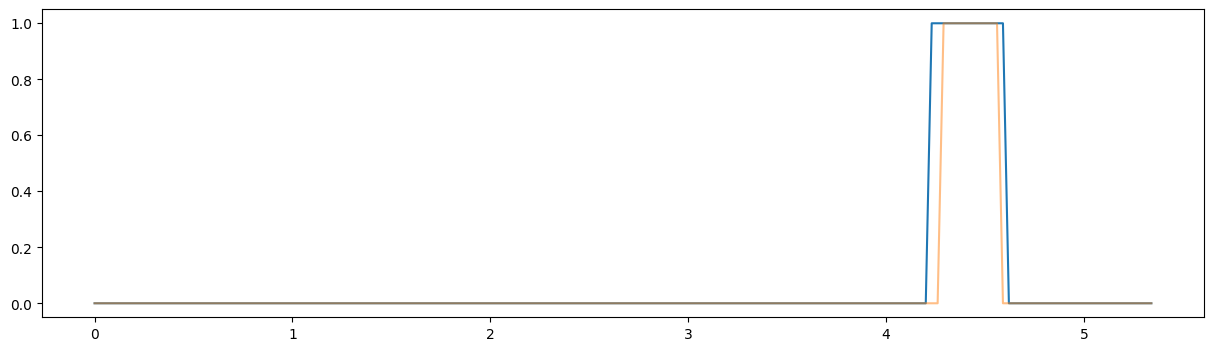

(0.9847328244274809, 0.9847328244274809, 0.7777777777777778)


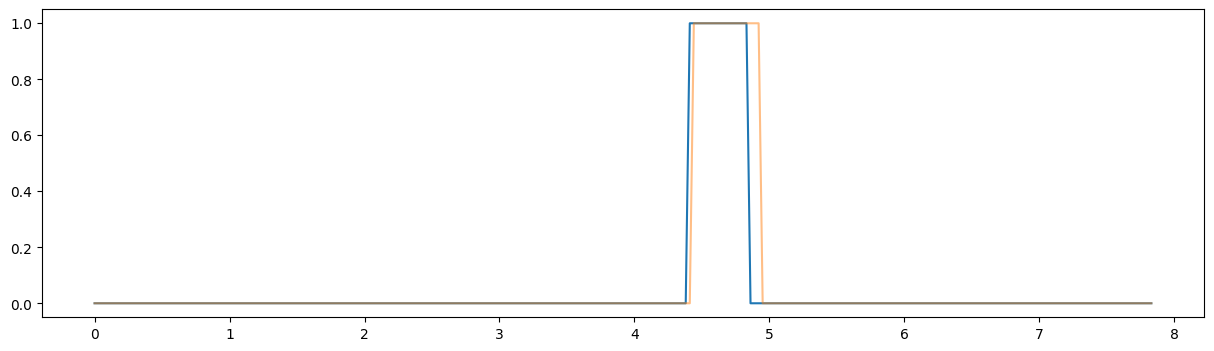

(0.9863013698630136, 0.9863013698630136, 0.9)


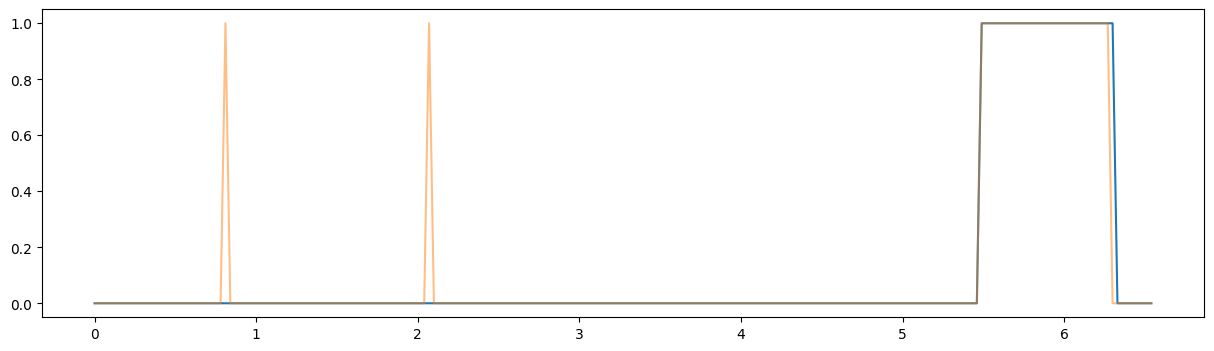

In [225]:
# top best
for i in ids[-3:]:
    s = test_utterance_id_to_scores[i]
    true = test_targets_per_utterance[i]
    pred = test_preds_per_utterance[i]
    wav, true2, _ = dataset[TRAIN:][i]
    assert np.allclose(true, true2)
    print(s)
    # display(IPython.display.Audio(wav, rate=FS))
    plt.figure(figsize=(15, 4))
    plt.plot(np.arange(0, true.shape[0] * 0.03 - 1e-6, 0.03), true, label="true")
    plt.plot(np.arange(0, pred.shape[0] * 0.03 - 1e-6, 0.03), pred, label="pred", alpha=0.5)

    plt.show()

(0.25842696629213485, 0.25842696629213485, 0.25842696629213485)


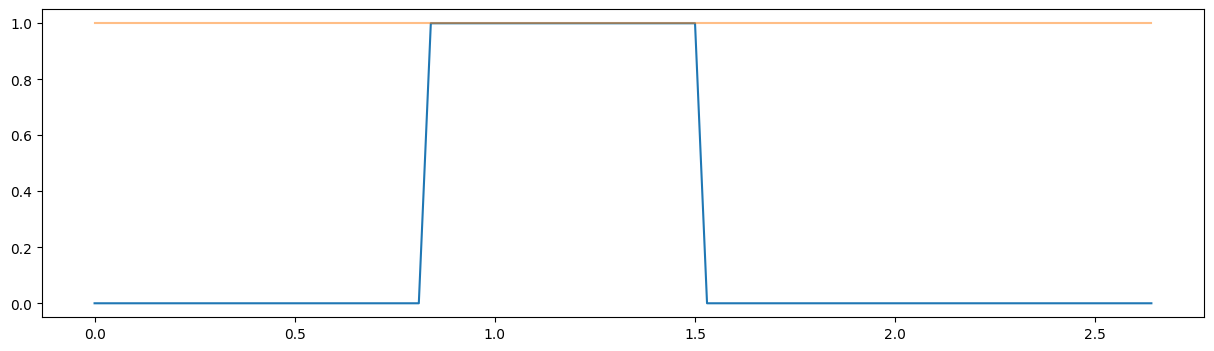

(0.34831460674157305, 0.34831460674157305, 0.30120481927710846)


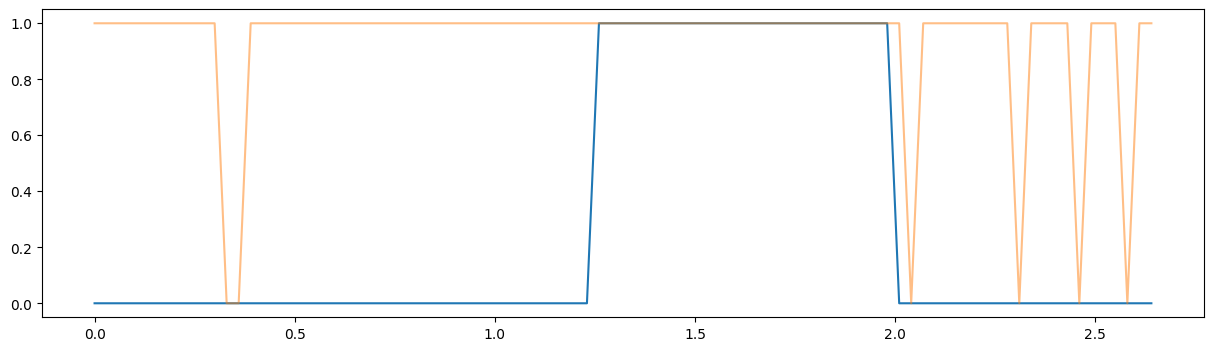

(0.5518867924528302, 0.5518867924528302, 0.25196850393700787)


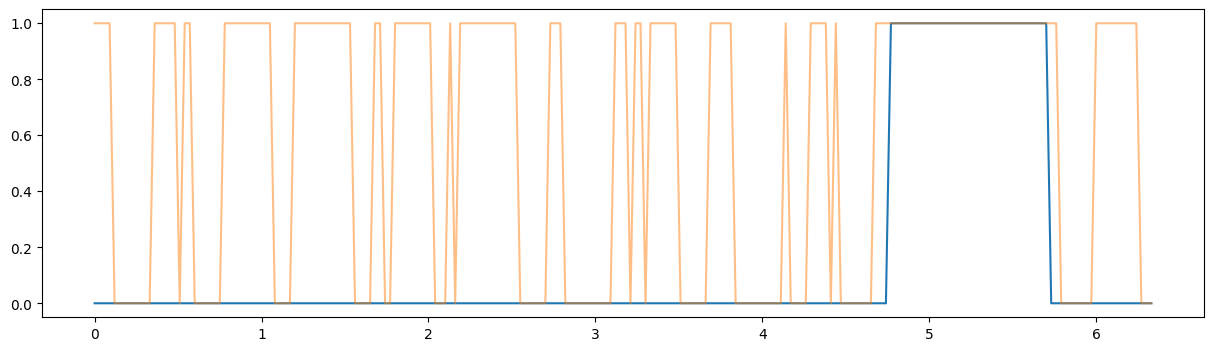

In [227]:
# top worst
# note: they are much noisier (e.g. with background music)
#  so obviousley energy based can't handle it
#  and predicts 1 [almost] everywhere
for i in ids[:3]:
    s = test_utterance_id_to_scores[i]
    true = test_targets_per_utterance[i]
    pred = test_preds_per_utterance[i]
    wav, true2, _ = dataset[TRAIN:][i]
    assert np.allclose(true, true2)
    print(s)
    # display(IPython.display.Audio(wav, rate=FS))
    plt.figure(figsize=(15, 4))
    plt.plot(np.arange(0, true.shape[0] * 0.03 - 1e-6, 0.03), true, label="true")
    plt.plot(np.arange(0, pred.shape[0] * 0.03 - 1e-6, 0.03), pred, label="pred", alpha=0.5)

    plt.show()